In [1]:
import cogsworth
import astropy.units as u
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import pandas as pd
import gala.dynamics as gd
import gala.potential as gp
from gala.units import galactic
from scipy.integrate import cumulative_trapezoid
from astropy.coordinates import SkyCoord

import sys
sys.path.append('../src')
import plotting, helpers, constants
from importlib import reload

In [2]:
%config InlineBackend.figure_format = 'retina'


pd.options.display.max_columns = 999

plt.rc('font', family='serif')
plt.rcParams['text.usetex'] = False
fs = 24

# update various fontsizes to match
params = {'figure.figsize': (12, 8),
          'legend.fontsize': 0.7*fs,
          'legend.title_fontsize': 0.8*fs,
          'axes.labelsize': fs,
          'xtick.labelsize': 0.9 * fs,
          'ytick.labelsize': 0.9 * fs,
          'axes.linewidth': 1.1,
          'xtick.major.size': 7,
          'xtick.minor.size': 4,
          'ytick.major.size': 7,
          'ytick.minor.size': 4}
plt.rcParams.update(params)

In [3]:
files = ["fiducial", "alpha_0.1", "alpha_0.5", "alpha_2.0", "alpha_10.0", "beta_0.0", "beta_0.5", "beta_1.0", "qcrit_caseB_0.001", "qcrit_caseB_1000"]
labels = ["Fiducial", r"$\alpha_{\rm CE} = 0.1$", r"$\alpha_{\rm CE} = 0.5$", r"$\alpha_{\rm CE} = 2.0$", r"$\alpha_{\rm CE} = 10.0$", r"$\beta = 0.0$", r"$\beta = 0.5$", r"$\beta = 1.0$", r"$q_{\rm crit, B} = 10^{-3}$", r"$q_{\rm crit, B} = 10^{3}$"]
colours = [constants.FILE_TO_COLOUR[f] for f in files]

In [4]:
pops, data = helpers.load_postprocessed_pops(files, labels, colours)

Loading post-processed data for Fiducial from fiducial
Loading post-processed data for $\alpha_{\rm CE} = 0.1$ from alpha_0.1
Loading post-processed data for $\alpha_{\rm CE} = 0.5$ from alpha_0.5
Loading post-processed data for $\alpha_{\rm CE} = 2.0$ from alpha_2.0
Loading post-processed data for $\alpha_{\rm CE} = 10.0$ from alpha_10.0
Loading post-processed data for $\beta = 0.0$ from beta_0.0
Loading post-processed data for $\beta = 0.5$ from beta_0.5
Loading post-processed data for $\beta = 1.0$ from beta_1.0
Loading post-processed data for $q_{\rm crit, B} = 10^{-3}$ from qcrit_caseB_0.001
Loading post-processed data for $q_{\rm crit, B} = 10^{3}$ from qcrit_caseB_1000


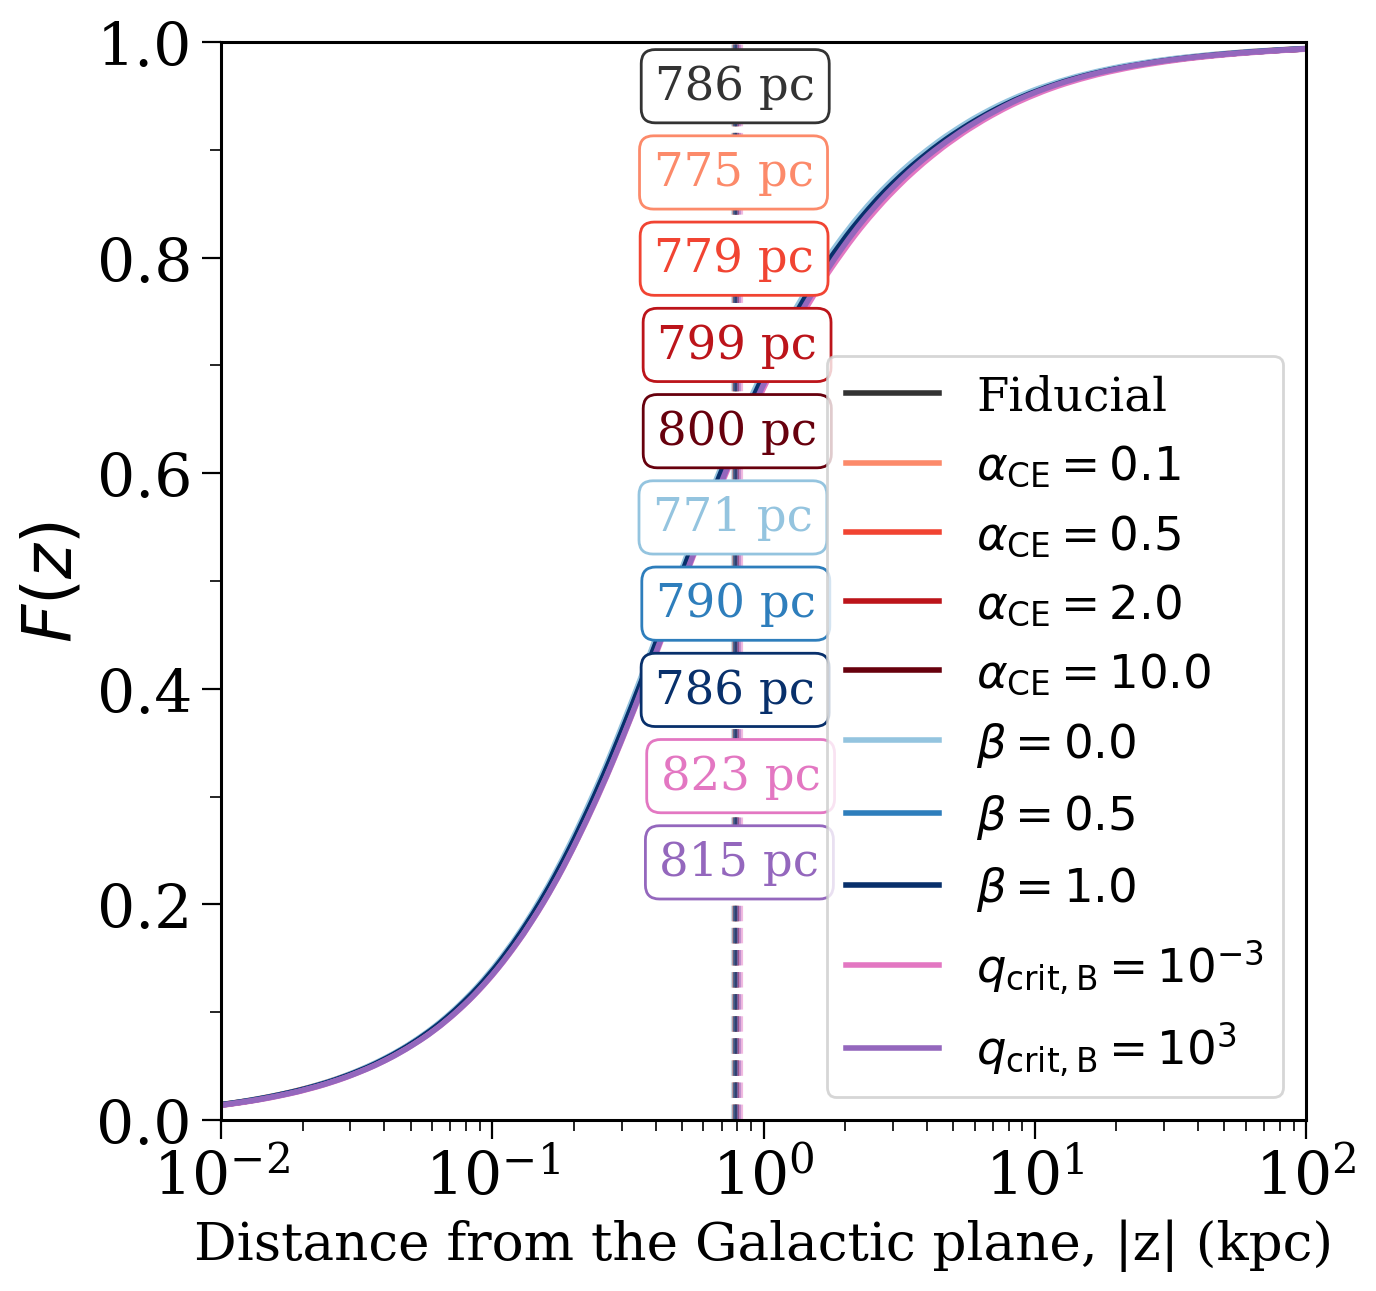

In [5]:
reload(plotting)
fig, ax = plt.subplots(figsize=(7, 7))

sep = 0.08
for pop, loc in zip(pops, [0.98 - sep * i for i in range(len(pops))]):
    plotting.estimate_scale_height_cdf(
        z=data[pop.label]["pos"]["BH"][:, 2][~data[pop.label]["escaped"]["BH"]],
        plot=True,
        label=pop.label,
        colour=pop.colour,
        show=False,
        fig=fig,
        ax=ax,
        xlim=(1e-2, 1e2),
        ylim=(0, 1),
        scale_height_loc=loc
    )


# ax.xaxis.set_minor_locator(mpl.ticker.MultipleLocator(0.1))
ax.yaxis.set_minor_locator(mpl.ticker.MultipleLocator(0.1))

# plt.savefig("../plots/scale_height_mt.pdf", format="pdf", bbox_inches="tight")

plt.show()

In [6]:
z_range = np.geomspace(0.05, 10, 250)

mean_masses = helpers.get_average_mass_at_z(
    abs_zs=[np.abs(data[pop.label]["pos"]["BH"][:, 2]) for pop in pops],
    bh_masses=[data[pop.label]["mass"]["BH"] for pop in pops],
    z_range=z_range,
    window_width=0.25,
    average_function=np.median
)

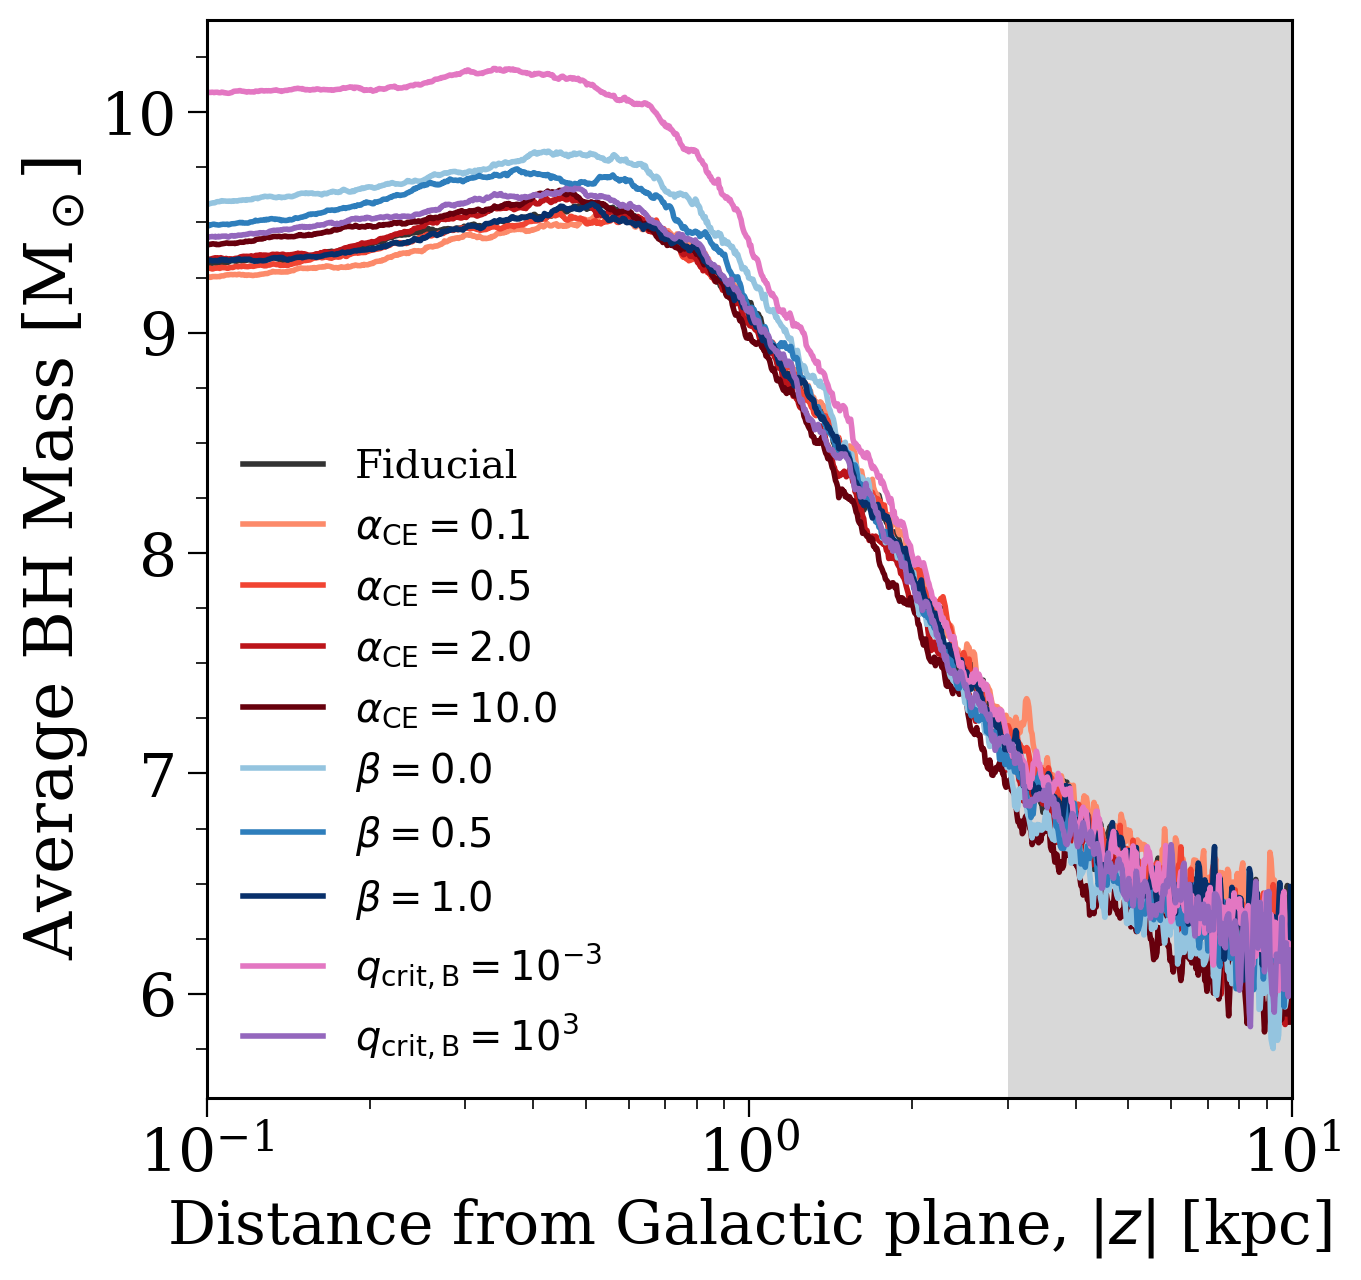

(<Figure size 700x700 with 1 Axes>,
 <Axes: xlabel='Distance from Galactic plane, $|z|$ [kpc]', ylabel='Average BH Mass [M$_\\odot$]'>)

In [7]:
plotting.plot_avg_mass_vs_z(
    mean_masses=mean_masses,
    labels=labels,
    colours=colours,
    z_maxes=[10] * len(pops),
    z_range=z_range,
    legend_kwargs={
        "loc": "lower left",
        "title": None,
        "fontsize": 0.6*fs,
        "frameon": False
    },
    save="../plots/average_bh_mass_vs_z_mt.pdf"
)

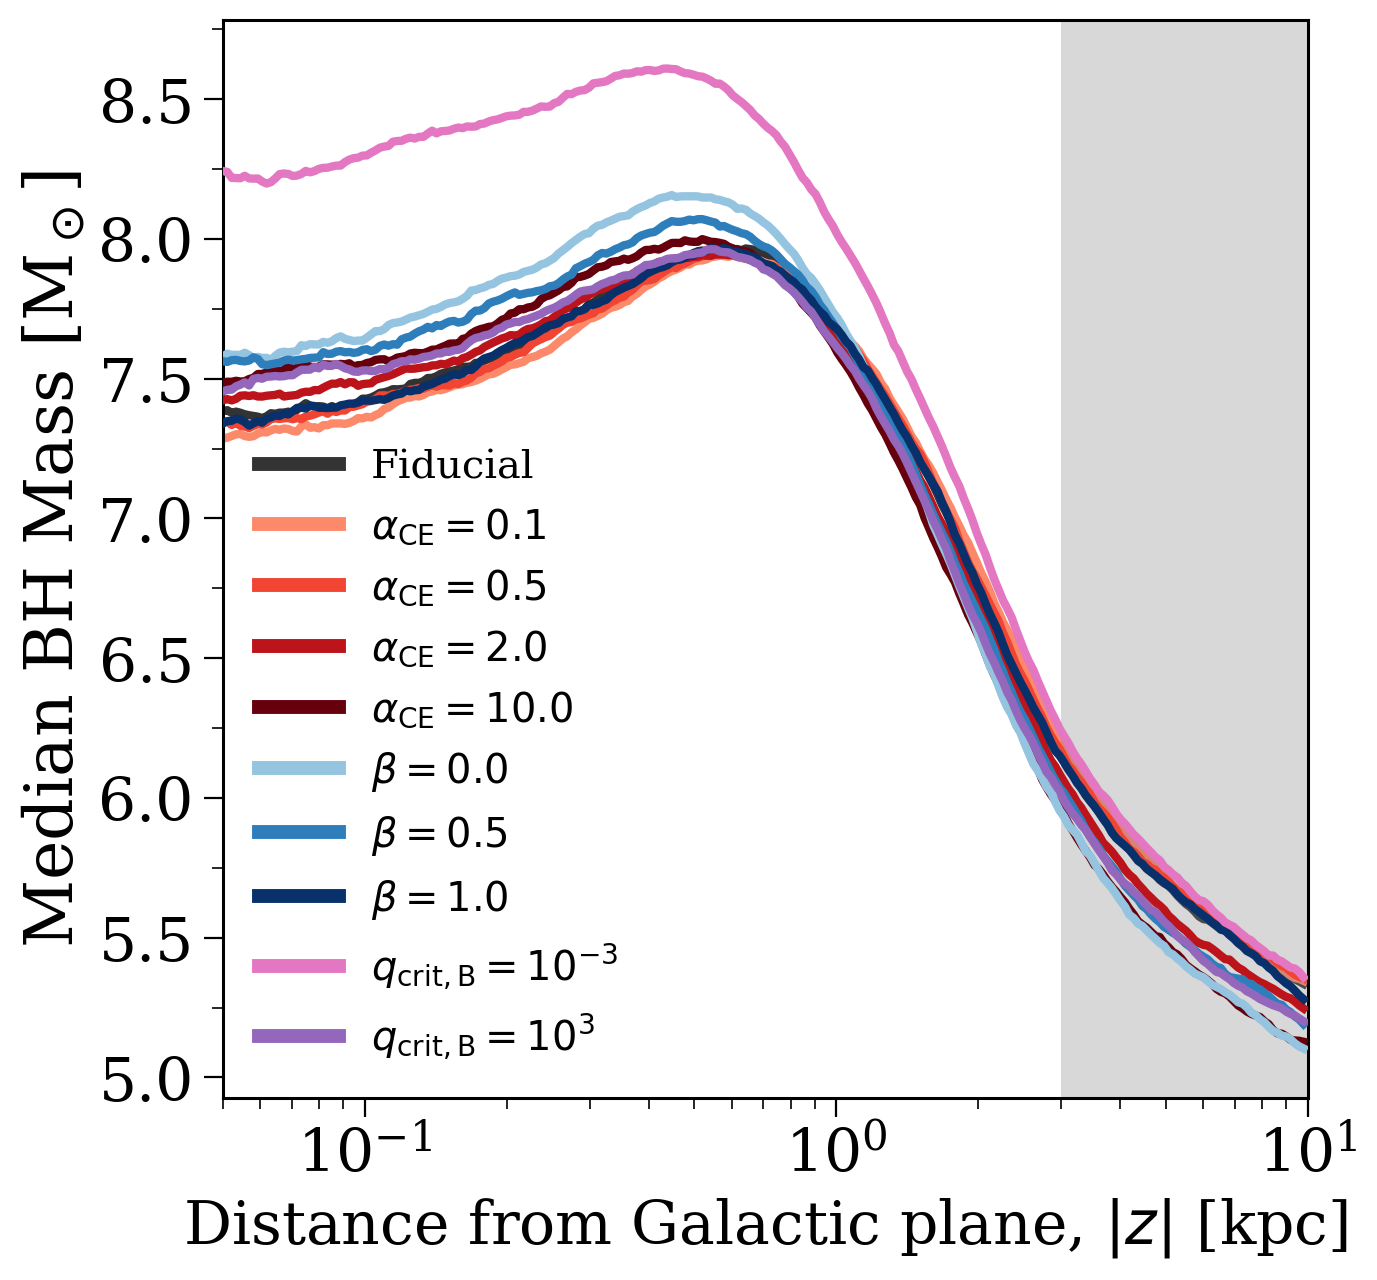

(<Figure size 700x700 with 1 Axes>,
 <Axes: xlabel='Distance from Galactic plane, $|z|$ [kpc]', ylabel='Median BH Mass [M$_\\odot$]'>)

In [7]:
plotting.plot_avg_mass_vs_z(
    mean_masses=mean_masses,
    labels=labels,
    colours=colours,
    z_maxes=[10] * len(pops),
    z_range=z_range,
    legend_kwargs={
        "loc": "lower left",
        "title": None,
        "fontsize": 0.6*fs,
        "frameon": False
    },
    save="../plots/average_bh_mass_vs_z_mt.pdf"
)